## Group 101

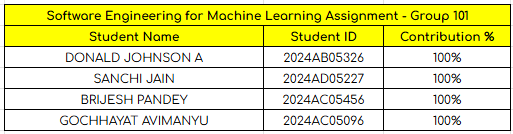

## Imports and Basic Configuration

In [1]:
# Section 1: Imports and config

import random
from typing import List, Tuple, Dict
import math
import numpy as np
from dataclasses import dataclass, asdict
import pprint

pp = pprint.PrettyPrinter(indent=2)

## Warehouse Grid and Simulator

In [2]:
# Section 2: Warehouse grid and simulator

Point = Tuple[int, int]  # (row, col)

@dataclass
class EpisodeLog:
    start: Point
    goal: Point
    path: List[Point]
    shortest_path_len: int
    travel_time: float
    collisions: int
    replans: int
    obstacle_density: float

In [3]:
class WarehouseGrid:
    def __init__(self, rows: int, cols: int, obstacle_prob: float = 0.1):
        self.rows = rows
        self.cols = cols
        self.grid = np.zeros((rows, cols), dtype=int)  # 0 = free, 1 = obstacle
        # Randomly add obstacles (not on border to keep it easier)
        for r in range(1, rows - 1):
            for c in range(1, cols - 1):
                if random.random() < obstacle_prob:
                    self.grid[r, c] = 1

    def is_free(self, p: Point) -> bool:
        r, c = p
        if r < 0 or r >= self.rows or c < 0 or c >= self.cols:
            return False
        return self.grid[r, c] == 0

    def obstacle_density(self) -> float:
        return float(self.grid.sum()) / (self.rows * self.cols)

    def display(self, robot: Point = None, start: Point = None, goal: Point = None):
        for r in range(self.rows):
            row_str = ""
            for c in range(self.cols):
                p = (r, c)
                if p == robot:
                    row_str += "R "
                elif p == start:
                    row_str += "S "
                elif p == goal:
                    row_str += "G "
                elif self.grid[r, c] == 1:
                    row_str += "X "
                else:
                    row_str += ". "
            print(row_str)
        print()

In [4]:
class RobotSimulator:
    def __init__(self, grid: WarehouseGrid, start: Point):
        self.grid = grid
        self.pos = start

    def step(self, next_pos: Point) -> Tuple[Point, bool]:
        """
        Attempt to move to next_pos.
        Returns (new_pos, collision_happened).
        """
        if not self.grid.is_free(next_pos):
            # collision with obstacle or wall, stay in place
            return self.pos, True
        self.pos = next_pos
        return self.pos, False

## Simple Path Planning (non-ML baseline: BFS shortest path)

In [5]:
# Section 3: Path planning (baseline BFS)

from collections import deque

MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right

def bfs_shortest_path(grid: WarehouseGrid, start: Point, goal: Point) -> List[Point]:
    queue = deque([start])
    visited = {start: None}  # parent
    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for dr, dc in MOVES:
            nxt = (current[0] + dr, current[1] + dc)
            if grid.is_free(nxt) and nxt not in visited:
                visited[nxt] = current
                queue.append(nxt)

    if goal not in visited:
        return []  # no path

    # reconstruct
    path = []
    p = goal
    while p is not None:
        path.append(p)
        p = visited[p]
    path.reverse()
    return path

## Online Navigation (Plan + Execute)

In [6]:
# Section 4: Execute a path and log an episode

TIME_PER_STEP = 1.0  # seconds per grid move (simplified)

def execute_path(grid: WarehouseGrid, start: Point, goal: Point) -> EpisodeLog:
    robot = RobotSimulator(grid, start)
    path = bfs_shortest_path(grid, start, goal)
    shortest_len = len(path) if path else 0

    travel_time = 0.0
    collisions = 0
    replans = 0  # kept for future; we don't replan in this simple version

    # If no path, just log failure
    if not path:
        return EpisodeLog(
            start=start,
            goal=goal,
            path=[],
            shortest_path_len=0,
            travel_time=0.0,
            collisions=0,
            replans=0,
            obstacle_density=grid.obstacle_density(),
        )

    for next_pos in path[1:]:
        new_pos, collided = robot.step(next_pos)
        travel_time += TIME_PER_STEP
        if collided:
            collisions += 1
            # in this simple version, we still continue along the path

    return EpisodeLog(
        start=start,
        goal=goal,
        path=path,
        shortest_path_len=shortest_len,
        travel_time=travel_time,
        collisions=collisions,
        replans=replans,
        obstacle_density=grid.obstacle_density(),
    )

## Logging (Raw Episodes)

In [7]:
# Section 5: Logging raw episodes

RAW_LOGS: List[EpisodeLog] = []

def run_random_task_and_log(grid: WarehouseGrid):
    # choose random free start and goal
    while True:
        start = (random.randint(0, grid.rows - 1), random.randint(0, grid.cols - 1))
        goal = (random.randint(0, grid.rows - 1), random.randint(0, grid.cols - 1))
        if grid.is_free(start) and grid.is_free(goal) and start != goal:
            break
    ep = execute_path(grid, start, goal)
    RAW_LOGS.append(ep)
    return ep

In [9]:
#example

grid = WarehouseGrid(rows=8, cols=8, obstacle_prob=0.2)
grid.display()

for _ in range(30):
    run_random_task_and_log(grid)

len(RAW_LOGS)

. . . . . . . . 
. . X . X . . . 
. . . . X . . . 
. . . . . . X . 
. . . . X . X . 
. . . . . . . . 
. . . X . . . . 
. . . . . . . . 



60

## Data Prep Pipeline (Pipes and Filters)

In [10]:
# Section 6: Data preparation pipeline (Pipes & Filters)

from copy import deepcopy

def collect_logs() -> List[Dict]:
    """F1 – Data collection: convert EpisodeLog objects to dicts."""
    return [asdict(ep) for ep in RAW_LOGS]

def clean_episodes(episodes: List[Dict]) -> List[Dict]:
    """F2 – Cleaning and validation."""
    cleaned = []
    for ep in episodes:
        if ep["shortest_path_len"] == 0:
            # no valid path, drop this episode
            continue
        if ep["travel_time"] <= 0:
            continue
        cleaned.append(ep)
    return cleaned

def engineer_features(episodes: List[Dict]) -> List[Dict]:
    """F3 – Feature engineering."""
    for ep in episodes:
        # simple features
        ep["path_len"] = len(ep["path"])
        ep["path_optimality_ratio"] = (
            ep["path_len"] / ep["shortest_path_len"]
            if ep["shortest_path_len"] > 0
            else 1.0
        )
        ep["time_per_step"] = ep["travel_time"] / ep["path_len"]
    return episodes

def compute_labels(episodes: List[Dict]) -> List[Dict]:
    """F4 – Label and metric computation."""
    # In this simple example, travel_time and collisions are already present.
    # We just make sure they exist and maybe add a 'safe' flag.
    for ep in episodes:
        ep["label_travel_time"] = ep["travel_time"]
        ep["label_collisions"] = ep["collisions"]
        ep["is_safe"] = 1 if ep["collisions"] == 0 else 0
    return episodes

def split_dataset(episodes: List[Dict], train_ratio=0.7, val_ratio=0.15):
    """F5 – Dataset splitting."""
    episodes = deepcopy(episodes)
    random.shuffle(episodes)
    n = len(episodes)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)
    train = episodes[:n_train]
    val = episodes[n_train:n_train + n_val]
    test = episodes[n_train + n_val:]
    return train, val, test

In [11]:
raw_eps = collect_logs()
cleaned = clean_episodes(raw_eps)
featurized = engineer_features(cleaned)
labeled = compute_labels(featurized)
train_set, val_set, test_set = split_dataset(labeled)

len(raw_eps), len(cleaned), len(train_set), len(val_set), len(test_set)

(60, 58, 40, 8, 10)

## Simple "model" that scores path

In [12]:
# Section 7: Multiple candidate paths + simple scoring

def neighbors(grid: WarehouseGrid, p: Point) -> List[Point]:
    res = []
    for dr, dc in MOVES:
        nxt = (p[0] + dr, p[1] + dc)
        if grid.is_free(nxt):
            res.append(nxt)
    return res

def greedy_random_path(grid: WarehouseGrid, start: Point, goal: Point, max_steps=200) -> List[Point]:
    """
    Not optimal. Just tries to move closer to goal with some randomness.
    """
    current = start
    path = [current]
    for _ in range(max_steps):
        if current == goal:
            break
        nbrs = neighbors(grid, current)
        if not nbrs:
            break
        # sort by manhattan distance, but pick among top 2 with randomness
        nbrs.sort(key=lambda p: abs(p[0] - goal[0]) + abs(p[1] - goal[1]))
        top = nbrs[: min(2, len(nbrs))]
        current = random.choice(top)
        path.append(current)
    if current != goal:
        return []
    return path

def score_path(path: List[Point], grid: WarehouseGrid) -> float:
    """
    Simple cost: length + alpha * estimated collision risk proxy.
    Here we approximate risk by average obstacle presence around path cells.
    """
    if not path:
        return math.inf
    path_len = len(path)
    # approximate "risk" as average of neighbors that are obstacles
    risk_sum = 0
    for p in path:
        r_neighbors = 0
        obs_neighbors = 0
        for dr, dc in MOVES:
            nbr = (p[0] + dr, p[1] + dc)
            if 0 <= nbr[0] < grid.rows and 0 <= nbr[1] < grid.cols:
                r_neighbors += 1
                if not grid.is_free(nbr):
                    obs_neighbors += 1
        if r_neighbors > 0:
            risk_sum += obs_neighbors / r_neighbors
    avg_risk = risk_sum / len(path)
    alpha = 5.0  # penalty weight for risk
    return path_len + alpha * avg_risk

In [13]:
def plan_path_with_model(grid: WarehouseGrid, start: Point, goal: Point, num_candidates=5) -> List[Point]:
    candidates = []

    # baseline shortest path
    sp = bfs_shortest_path(grid, start, goal)
    if sp:
        candidates.append(sp)

    # additional greedy random paths
    for _ in range(num_candidates - 1):
        gp = greedy_random_path(grid, start, goal)
        if gp:
            candidates.append(gp)

    if not candidates:
        return []

    # score and pick best
    best_path = min(candidates, key=lambda p: score_path(p, grid))
    return best_path

## Main Demo Run (Monolithic Wiring)

In [14]:
# Section 8: Main demo

def main_demo():
    grid = WarehouseGrid(rows=8, cols=8, obstacle_prob=0.2)
    # choose a random start and goal
    while True:
        start = (random.randint(0, grid.rows - 1), random.randint(0, grid.cols - 1))
        goal = (random.randint(0, grid.rows - 1), random.randint(0, grid.cols - 1))
        if grid.is_free(start) and grid.is_free(goal) and start != goal:
            break

    print("Warehouse layout:")
    grid.display(start=start, goal=goal)

    path = plan_path_with_model(grid, start, goal)
    print("Planned path:", path)

    ep = execute_path(grid, start, goal)
    print("Episode log:")
    pp.pprint(asdict(ep))

    # log and update datasets
    RAW_LOGS.append(ep)
    raw_eps = collect_logs()
    cleaned = clean_episodes(raw_eps)
    featurized = engineer_features(cleaned)
    labeled = compute_labels(featurized)
    train_set, val_set, test_set = split_dataset(labeled)

    print(f"Dataset sizes: raw={len(raw_eps)}, cleaned={len(cleaned)}, "
          f"train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")

main_demo()

Warehouse layout:
. . . . . . . . 
. . . X . . . . 
. . . . . . . . 
. X . . X . . . 
. X . . . . X . 
. X . . . . . . 
. X X . . . X S 
G . . . . . . . 

Planned path: [(6, 7), (7, 7), (7, 6), (7, 5), (7, 4), (7, 3), (7, 2), (7, 1), (7, 0)]
Episode log:
{ 'collisions': 0,
  'goal': (7, 0),
  'obstacle_density': 0.140625,
  'path': [ (6, 7),
            (7, 7),
            (7, 6),
            (7, 5),
            (7, 4),
            (7, 3),
            (7, 2),
            (7, 1),
            (7, 0)],
  'replans': 0,
  'shortest_path_len': 9,
  'start': (6, 7),
  'travel_time': 8.0}
Dataset sizes: raw=61, cleaned=59, train=41, val=8, test=10
